# Part 5 — What runs next, and what does not

Live answers from the cluster's Prometheus: our gateway queue next to SGLang's
waiting / running / retracted queue, per worker, under the application's traffic.

**How to run (GPU session):**
1. Start the stack (engine + gateway + Prometheus), see `docs/h100-runbook.md`.
2. From the laptop, tunnel Prometheus: `ssh -L 19090:127.0.0.1:19090 <gpu-host>`.
3. Drive traffic: the labelled Locust mix (`experiments/locustfile.py`).
4. Run all cells, then save the notebook **with outputs** and export the plots to `plots/`.

The query helpers are tested in `tests/unit/test_prometheus_snapshot.py`.

In [1]:
import os
import sys
import time
from datetime import datetime
from pathlib import Path

import httpx
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(ROOT))

from experiments.prometheus_snapshot import instant, queue_snapshot, range_series, shed_counts

PROM_URL = os.environ.get("PROM_URL", "http://127.0.0.1:19090")
WINDOW_MIN = int(os.environ.get("WINDOW_MIN", "15"))   # how far back the plots look
PLOTS = ROOT / "plots"
END = time.time()
START = END - WINDOW_MIN * 60

prom = httpx.Client(base_url=PROM_URL, timeout=10)
print(f"Prometheus {PROM_URL}, window {datetime.fromtimestamp(START):%H:%M:%S}–{datetime.fromtimestamp(END):%H:%M:%S}")

Prometheus http://127.0.0.1:29090, window 22:30:08–00:00:08


## 0. Is the scrape live?

A design without a live `/metrics` scrape fails. Every target must be `1`.

In [2]:
for sample in instant(prom, "up"):
    name = sample.labels.get("worker") or sample.labels.get("job")
    print(f"{name:12} up={sample.value:.0f}")

worker-a     up=1
prometheus   up=1
gateway      up=1
worker-b     up=1


## 1. Who sits in our queue vs the engine's waiting queue?

* **gateway queued** — admitted and placed, waiting in *our* per-worker priority queue
  (interactive before batch). We can still shed it (`timeout_queue`).
* **gateway in flight** — dispatched to the engine, not finished.
* **engine waiting / running / retracted** — SGLang's own scheduler (`sglang:num_queue_reqs`,
  `num_running_reqs`, `num_retracted_reqs`). We do not reimplement it.

Because the gateway's dispatch cap (8) equals `--max-running-requests` (8), the engine's
waiting queue should stay near 0 and the backlog should be visible in *our* queue.

In [3]:
snapshot = queue_snapshot(prom)
header = f"{'worker':10} {'gw queued':>10} {'gw in flight':>13} {'eng waiting':>12} {'eng running':>12} {'retracted':>10} {'KV':>6}"
print(header)
print("-" * len(header))
for worker, q in snapshot.items():
    fmt = lambda v, spec=".0f": "—" if v is None else format(v, spec)
    print(f"{worker:10} {fmt(q.gateway_queued):>10} {fmt(q.gateway_in_flight):>13} {fmt(q.engine_waiting):>12} "
          f"{fmt(q.engine_running):>12} {fmt(q.engine_retracted):>10} {fmt(q.kv_usage, '.1%'):>6}")

worker      gw queued  gw in flight  eng waiting  eng running  retracted     KV
-------------------------------------------------------------------------------
worker-a            0             0            0            0          0   0.0%
worker-b            0             0            0            0          0   0.0%


## 2. `orch_replica_queue_depth` — which pod, under which mix?

Our queue and the engine's queue per worker over the Locust run.

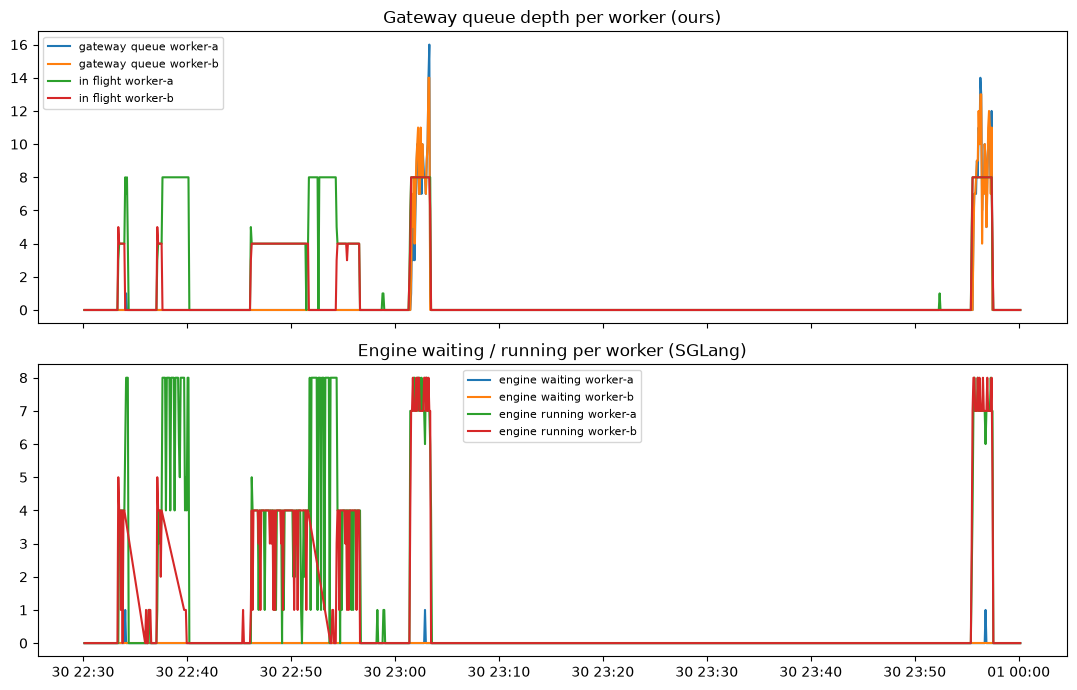

In [4]:
def plot(ax, promql, label, title, step="5s"):
    for series in range_series(prom, promql, start=START, end=END, step=step):
        times = [datetime.fromtimestamp(t) for t, _ in series.points]
        ax.plot(times, [v for _, v in series.points], label=label.format(**series.labels))
    ax.set_title(title)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
plot(axes[0], "orch_replica_queue_depth", "gateway queue {worker}", "Gateway queue depth per worker (ours)")
plot(axes[0], "orch_replica_in_flight", "in flight {worker}", "Gateway queue depth per worker (ours)")
plot(axes[1], "sglang:num_queue_reqs", "engine waiting {worker}", "Engine waiting / running per worker (SGLang)")
plot(axes[1], "sglang:num_running_reqs", "engine running {worker}", "Engine waiting / running per worker (SGLang)")
fig.tight_layout()
fig.savefig(PLOTS / "part5-queue-depth-by-pod.png", dpi=120)

## 3. KV full after admit — shed at the door, or does the engine preempt?

Door: gateway sheds by reason (`kv_pressure`, `queue_full`, `timeout_queue`, `tenant_tokens`).
Engine: SGLang retractions (preemptions) in the same window. Admission stops above 90 % KV,
so retractions should stay at 0; the gateway does not fix OOM, it avoids adding work.

In [5]:
window = f"{WINDOW_MIN}m"
print(f"Shed at the door, last {window}:")
for (reason, code), count in sorted(shed_counts(prom, window=window).items()):
    print(f"  {reason:20} {code}  {count:8.0f}")
for sample in instant(prom, f"increase(sglang:num_retracted_reqs[{window}])"):
    print(f"Engine retractions on {sample.labels.get('worker')}: {sample.value:.0f}")
for sample in instant(prom, f"max_over_time(sglang:full_token_usage[{window}])"):
    print(f"Peak KV usage on {sample.labels.get('worker')}: {sample.value:.1%}")

Shed at the door, last 90m:
  queue_full           503         1
  tenant_tokens        429       617
  timeout_queue        504       153


Engine retractions on worker-a: 0
Engine retractions on worker-b: 0
Peak KV usage on worker-a: 8.6%
Peak KV usage on worker-b: 8.8%


## 4. PagedAttention vs radix cache — which one saved memory on our shared-prefix mix?

SGLang's token pool packs KV without fragmentation (the PagedAttention idea), but on our mix
the saving comes from **reuse**: the shared Router/Tutor/tool prefix is stored once per worker.
A high cache hit rate with low KV usage is the evidence.

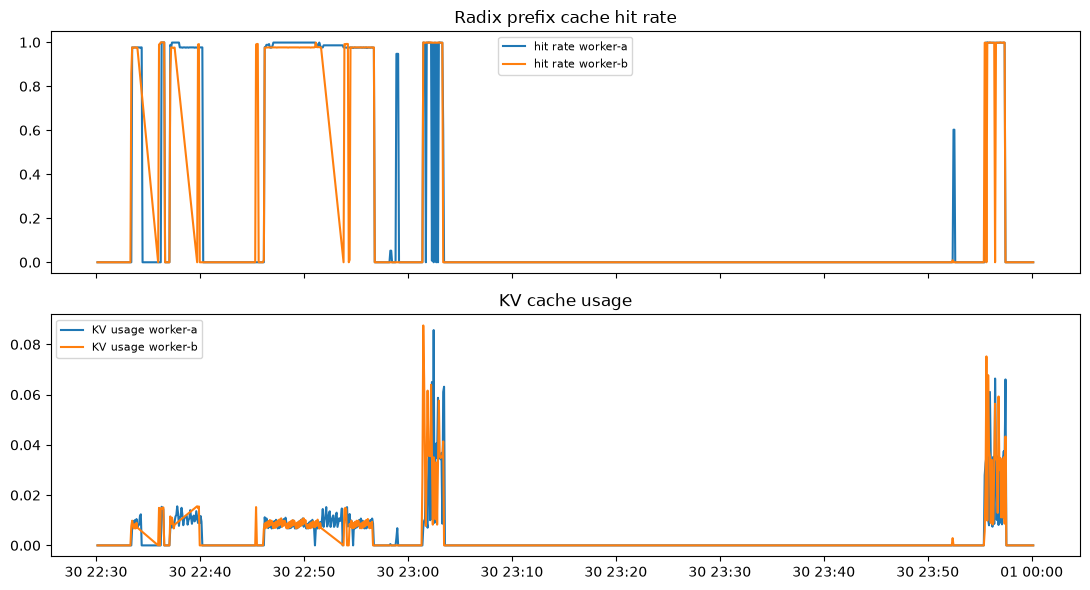

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
plot(axes[0], "sglang:cache_hit_rate", "hit rate {worker}", "Radix prefix cache hit rate")
plot(axes[1], "sglang:full_token_usage", "KV usage {worker}", "KV cache usage")
fig.tight_layout()
fig.savefig(PLOTS / "part5-shared-prefix-kv.png", dpi=120)

## 5. Hops and interactive priority

* Hops: placements that moved a shared prefix to a worker that did not hold it
  (`prefix_then_load` should keep this low); evictions from the hop ledger.
* Interactive before batch and tenant windows: sheds per reason over time.

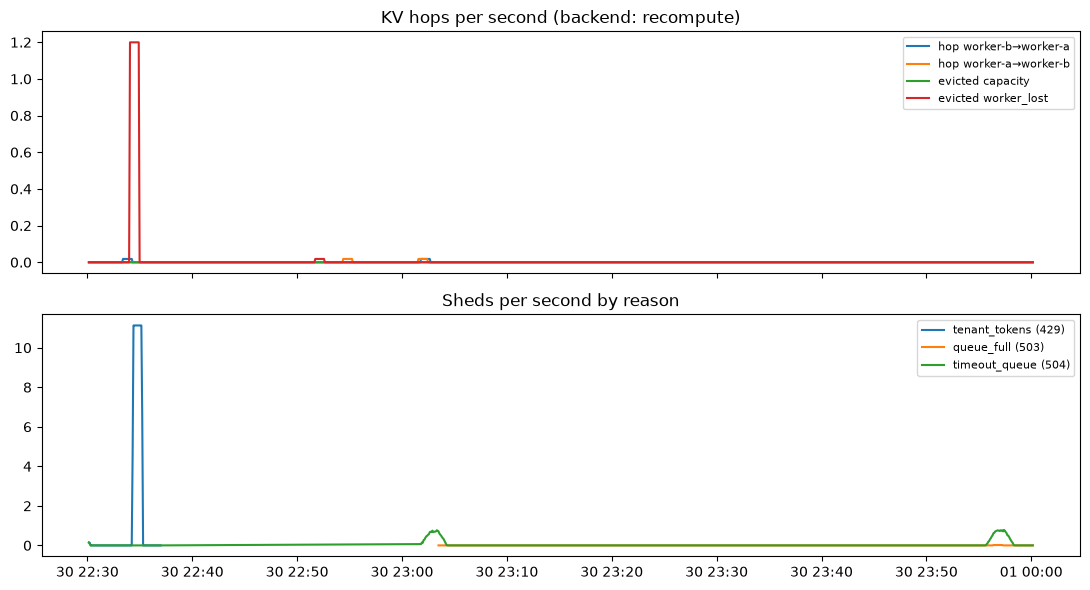

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
plot(axes[0], "sum by (src, dst) (rate(orch_hop_total[1m]))", "hop {src}→{dst}", "KV hops per second (backend: recompute)")
plot(axes[0], "sum by (cause) (rate(orch_hop_evictions_total[1m]))", "evicted {cause}", "KV hops per second (backend: recompute)")
plot(axes[1], "sum by (reason, code) (rate(orch_shed_total[1m]))", "{reason} ({code})", "Sheds per second by reason")
fig.tight_layout()
fig.savefig(PLOTS / "part5-hops-and-sheds.png", dpi=120)

## 6. After a worker returns — slam or ramp?

Kill one worker during the Locust run (`kubectl delete pod sglang-1`) and set `WINDOW_MIN` to cover
it. The gateway starts a returning worker at `ramp_limit = 1` and doubles it per 5 s poll
(1 → 2 → 4 → 8) while the engine queue is empty, so its placements should rise over ~15 s
instead of jumping to the full cap.

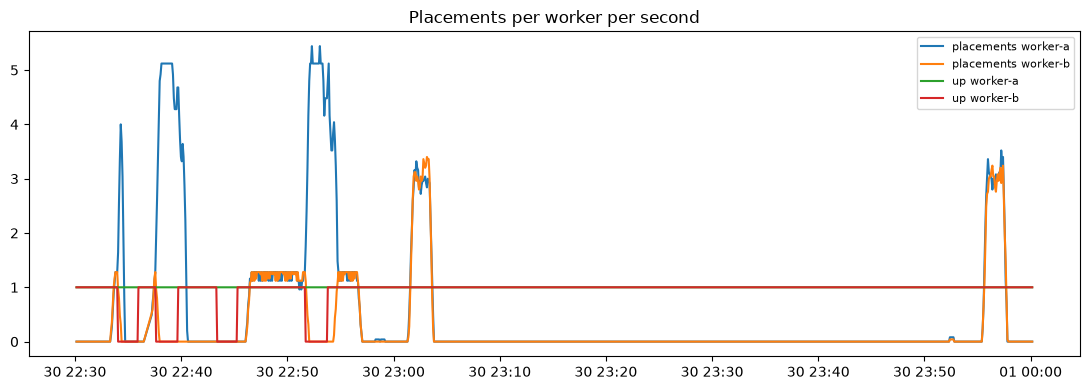

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
plot(ax, "sum by (worker) (rate(orch_place_total[30s]))", "placements {worker}", "Placements per worker per second")
plot(ax, "up{job='sglang'}", "up {worker}", "Placements per worker per second")
fig.tight_layout()
fig.savefig(PLOTS / "part5-ramp-after-return.png", dpi=120)

## 7. Answers that are configuration, not a scrape

| Question | Answer |
|---|---|
| A 32k RAG retrieve and a short agent decode are both ready — who goes first? | A 32k prompt never enters: the guard rejects it (`prompt_too_long`, context 8,192). Inside 8k **we** order our queue (interactive before batch, `X-Request-Class`); once dispatched, **SGLang** interleaves: `--chunked-prefill-size=2048` splits a long prefill so running decodes keep stepping. |
| Chunked prefill / continuous batching flags | `--chunked-prefill-size=2048`, `--max-running-requests=8` (decode CUDA graphs for bs 1, 2, 4, 8), `max_prefill_tokens=16384` (default), `--context-length=8192`. |
| Client gone — who frees the KV? | Streaming: the client disconnect closes the gateway→engine stream, SGLang aborts the request and frees its KV; the shared prefix stays in the radix cache as evictable. Queued: an expired request is never dispatched. **Proven on the A100 (30 Sep):** a stream with `max_tokens` 1000 was dropped by the client after 2 s; 3 s after the start `sglang:num_running_reqs` was 0 on both workers, vs 1.0 in a control run where the client stayed (`metrics/client-abort-a100-2026-09-30.txt`, `make abort`). |
| After a worker returns: slam or ramp? | Ramp. If the plot in section 6 does not cover a kill, the evidence is `metrics/kill-ramp-a100-2026-09-30.txt`: 1,200/1,200 requests OK, the returning worker got 0 user requests for 19 s after its 5 warmups, then its normal share. Before the ramp: 8 requests within 2 s. |
| Where does the engine scheduler sit vs our admit / place / queue? | Gateway (`gateway/`): guard → tenant window → admit → place → our queue. Engine (SGLang): waiting → running → retract, chunked prefill, radix cache. See `DESIGN.md` Part 2. |